# Baseline Model Conv2D (Shared Parameters)

In [1]:
import os
print(os.environ.get("LD_LIBRARY_PATH"))

/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cublas/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cuda_runtime/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cudnn/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cufft/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cusolver/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cusparse/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/nccl/lib:


## Import Libraries

In [2]:
import os

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
tf.test.is_built_with_cuda()

I0000 00:00:1778496980.357468    8158 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


True

## Config

In [3]:
TRAIN_DIR  = '../../data/intel/seg_train'
VAL_DIR    = '../../data/intel/seg_test'
TEST_DIR   = '../../data/intel/seg_pred'
MODEL_DIR  = '../../data/models/cnn'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE    = (150, 150)
BATCH_SIZE  = 64
EPOCHS      = 10
NUM_CLASSES = 6
LR          = 1e-4
VAL_SPLIT   = 0.2

## Import Dataset

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

normalization = keras.layers.Rescaling(1.0 / 255.0)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
)
class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

train_ds = (
    train_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

train_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
val_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
test_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=1, label_mode="int", shuffle=False
))

print("Kelas      :", {name: i for i, name in enumerate(class_names)})
print(f"Train      : {train_count} gambar")
print(f"Validation : {val_count} gambar")
print(f"Test       : {test_count} gambar")

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Kelas      : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Train      : 11230 gambar
Validation : 2804 gambar
Test       : 3000 gambar


## CNN Model Baseline Architecture

In [6]:
MODEL_NAME = 'Layer-2-64-128-5x5-maxpool'
model = keras.Sequential([
    keras.layers.Input(shape=IMG_SIZE + (3,), name='input'),
    keras.layers.Conv2D(64, (5, 5), activation='relu', padding='valid', name='conv2s_1'),
    keras.layers.MaxPooling2D((2, 2), name='maxpool_1'),
    keras.layers.Conv2D(128, (5, 5), activation='relu', padding='valid', name='conv2s_2'),
    keras.layers.MaxPooling2D((2, 2), name='maxpool_2'),
    keras.layers.Flatten(name='flatten'),
    keras.layers.Dense(128, activation='relu', name='dense_1'),
    keras.layers.Dense(6, activation='softmax', name='output'),
], name=MODEL_NAME)
model.summary()

I0000 00:00:1778497132.564922    8158 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5173 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "Layer-2-64-128-5x5-maxpool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2s_1 (Conv2D)               │ (None, 220, 220, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2s_2 (Conv2D)               │ (None, 106, 106, 128)  │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 53, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 359552)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    46,022,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,233,350 (176.37 MB)

 Trainable params: 46,233,350 (176.37 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation and Training

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callback = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'../../data/models/cnn/{MODEL_NAME}.h5',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callback,
    verbose=1
)

Epoch 1/3


I0000 00:00:1778497147.876115    8158 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1778497151.061025    8882 service.cc:153] XLA service 0x7359d00326f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778497151.061088    8882 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.5.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778497151.125751    8882 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778497151.598889    8882 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778497151.635588    8882 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1558__.30


  1/351 ━━━━━━━━━━━━━━━━━━━━ 2:08:48 22s/step - accuracy: 0.0625 - loss: 1.8327

I0000 00:00:1778497169.798877    8882 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


335/351 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.4357 - loss: 1.8680

...


Epoch 1: val_loss improved from None to 0.92155, saving model to ../../data/models/cnn/layer-2-64-128-5x5-maxpool.h5


W0000 00:00:1778497389.021673    8158 cpu_allocator_impl.cc:82] Allocation of 184090624 exceeds 10% of free system memory.
W0000 00:00:1778497397.614967    8158 cpu_allocator_impl.cc:82] Allocation of 184090624 exceeds 10% of free system memory.
W0000 00:00:1778497399.523280    8158 cpu_allocator_impl.cc:82] Allocation of 184090624 exceeds 10% of free system memory.


351/351 ━━━━━━━━━━━━━━━━━━━━ 262s 686ms/step - accuracy: 0.5514 - loss: 1.1972 - val_accuracy: 0.6362 - val_loss: 0.9216
Epoch 2/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.6876 - loss: 0.8132
Epoch 2: val_loss improved from 0.92155 to 0.77111, saving model to ../../data/models/cnn/layer-2-64-128-5x5-maxpool.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 190s 532ms/step - accuracy: 0.6970 - loss: 0.7982 - val_accuracy: 0.7140 - val_loss: 0.7711
Epoch 3/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.7869 - loss: 0.5787
Epoch 3: val_loss improved from 0.77111 to 0.70793, saving model to ../../data/models/cnn/layer-2-64-128-5x5-maxpool.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 181s 515ms/step - accuracy: 0.7929 - loss: 0.5728 - val_accuracy: 0.7525 - val_loss: 0.7079
Restoring model weights from the end of the best epoch: 3.


## Evaluation

In [8]:
y_pred_proba = model.predict(test_ds)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds])

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 465ms/step
Macro F1 Score: 0.7451


## Plot

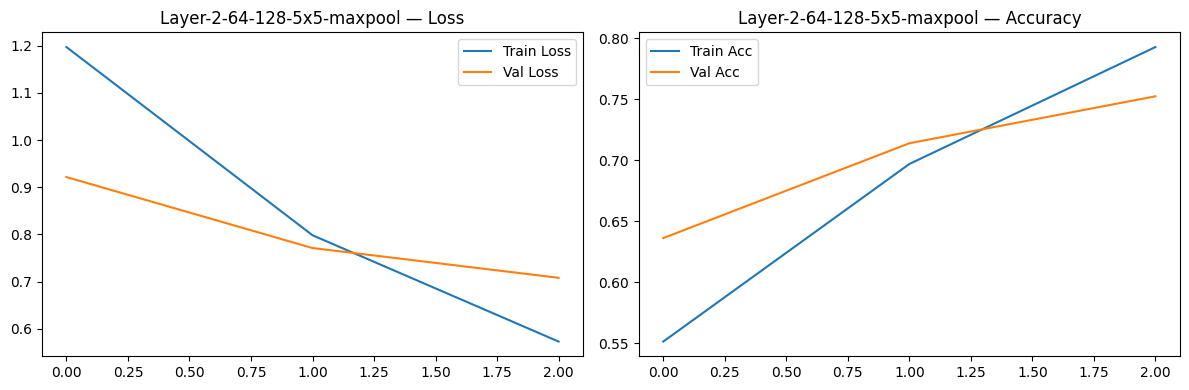

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'],label='Val Loss')
ax1.set_title(f'{MODEL_NAME} — Loss'); ax1.legend()
ax2.plot(history.history['accuracy'],label='Train Acc')
ax2.plot(history.history['val_accuracy'],label='Val Acc')
ax2.set_title(f'{MODEL_NAME} — Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, f'{MODEL_NAME}_curve.png'), dpi=100)
plt.show()